In [1]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.stats import norm
from scipy import interpolate
from scipy.optimize import minimize
from time import time
from scipy.optimize import curve_fit
import scipy.constants as cs
from datetime import datetime
from scipy.io import savemat, loadmat
import os
import shutil
import json
import glob
from tabulate import tabulate
from scipy.optimize import fsolve
from uncertainties import ufloat
from uncertainties import unumpy as unp
%matplotlib inline

In [2]:
def BoseEinsteinInverse(f,n):
    return cs.h*f/(cs.k*np.log(1/n+1))

def fitSdiffCoh(xdata, ydata, t0, chi, T2, n, A):
    guess = [t0, chi, T2, n, A]
    full_output = curve_fit(T2CohwithScaling, xdata, ydata, guess, full_output=True)
    return full_output

def T2CohwithScaling(t,t0,chi,T2, n, A):
    return T2Coh(t-t0, chi,T2,nguess)*A

def T2Coh(t,chi,T2, n): # from Ammpendix E3 of Number-Resolved Photocounter for Propagating Microwave Mode R.
    return np.cos(n * np.sin(chi*t)) * np.exp( n * (np.cos(chi*t)-1)-t/T2)

In [3]:
home_dir = os.getcwd()
print('Home dir: ' + home_dir)
folder = r'\Fig_4c\QubitCavTemp'
print(home_dir + folder)
files = glob.glob(home_dir + folder + '\\T2_*.mat')
print(files)

Home dir: C:\Users\twerner\Desktop\ResponseEditorialChanges
C:\Users\twerner\Desktop\ResponseEditorialChanges\Fig_4c\QubitCavTemp
['C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges\\Fig_4c\\QubitCavTemp\\T2_0Hz.mat', 'C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges\\Fig_4c\\QubitCavTemp\\T2_1000Hz.mat', 'C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges\\Fig_4c\\QubitCavTemp\\T2_10Hz.mat', 'C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges\\Fig_4c\\QubitCavTemp\\T2_250Hz.mat', 'C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges\\Fig_4c\\QubitCavTemp\\T2_500Hz.mat', 'C:\\Users\\twerner\\Desktop\\ResponseEditorialChanges\\Fig_4c\\QubitCavTemp\\T2_50Hz.mat']


In [4]:
#Fit parameters from earlier fits
t0_array = [3.56857e-08, 1.2297e-08, 1.24957e-08, 1.47633e-07, 1.49471e-07, 1.64158e-07]
chi_x2pi_array = np.asarray([4.80681e+07, 4.08407e+07, 4.08407e+07, 3.01314e+07, 2.33384e+07, 2.11837e+07])
T2_array = np.asarray([1.47841e-06, 1.40018e-06, 1.14092e-06, 7.68318e-07, 6.39481e-07, 4.47489e-07])
n_array = [0.0059, 0.00587, 0.00605, 0.0154, 0.0466, 0.1114]
A0_array = [0.978358, 1, 1, 0.837768, 0.834959, 0.782578]

T_array = [ 82.5,  82.4,  82.9, 101.2, 136.2, 184.2]
std_dev_array = [2.4, 2.9, 3.4, 2.9, 1.3, 1.9]

In [5]:
Adiff_file = 'T2_0Hz.mat'
t0_init = t0_array[0]
chi_x2pi_init = chi_x2pi_array[0]
T2_init = T2_array[0]
n_init = n_array[0]
A0_init = A0_array[0]
std_dev = std_dev_array[0]

# Adiff_file = 'T2_10Hz.mat'
# t0_init = t0_array[1]
# chi_x2pi_init = chi_x2pi_array[1]
# T2_init = T2_array[1]
# n_init = n_array[1]
# A0_init = A0_array[1]
# std_dev = std_dev_array[1]

# Adiff_file = 'T2_50Hz.mat'
# t0_init = t0_array[2]
# chi_x2pi_init = chi_x2pi_array[2]
# T2_init = T2_array[2]
# n_init = n_array[2]
# A0_init = A0_array[2]
# std_dev = std_dev_array[2]

# Adiff_file = 'T2_250Hz.mat'
# t0_init = t0_array[3]
# chi_x2pi_init = chi_x2pi_array[3]
# T2_init = T2_array[3]
# n_init = n_array[3]
# A0_init = A0_array[3]
# std_dev = std_dev_array[3]

# Adiff_file = 'T2_500Hz.mat'
# t0_init = t0_array[4]
# chi_x2pi_init = chi_x2pi_array[4]
# T2_init = T2_array[4]
# n_init = n_array[4]
# A0_init = A0_array[4]
# std_dev = std_dev_array[4]

# Adiff_file = 'T2_1000Hz.mat'
# t0_init = t0_array[5]
# chi_x2pi_init = chi_x2pi_array[5]
# T2_init = T2_array[5]
# n_init = n_array[5]
# A0_init = A0_array[5]
# std_dev = std_dev_array[5]


data = loadmat(home_dir + folder + r'\\' + Adiff_file)
Adiff = np.squeeze(data['Adiff'])
t_ns = np.squeeze(data['t_ns'])

C:\ProgramData\Anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Fit worked!
Cavity temperature: 82.46900387590239 mK


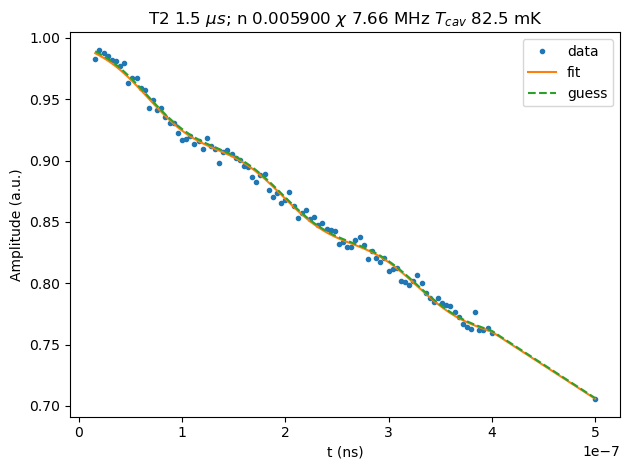

In [6]:
resonator_freq = 8.83019e9

xmax = 600
xdata = t_ns[t_ns<xmax]*1e-9
ydata = Adiff[t_ns<xmax]
delta = 0/(2*1e3)

t0guess = t0_init
chiguess = chi_x2pi_init
T2guess = T2_init
nguess = n_init
Aguess = A0_init

p0guess = [t0guess, chiguess, T2guess, nguess, Aguess]
try:
    fit_params = fitSdiffCoh(xdata, ydata, *p0guess)
    popt = fit_params[0]
    Tcavfit = BoseEinsteinInverse(resonator_freq,popt[3])*1000
    print('Fit worked!')
except:
    print('Fit did not work! Try different initial values...')
    popt = p0guess
    Tcavfit = BoseEinsteinInverse(resonator_freq,popt[3])*1000

print('Cavity temperature: ' + str(Tcavfit) +  ' mK')

plt.figure()
plt.title('T2 ' + '{:.1f}'.format(popt[2]*1e6) + ' $\mu s$; n ' + '{:.6f}'.format(popt[3]) + ' $\chi $ ' + '{:.2f}'.format(popt[1]/2/np.pi*1e-6) + ' MHz $T_{cav}$ ' + '{:.1f}'.format(Tcavfit) + ' mK')
plt.plot(xdata, ydata, '.', label='data')
plt.plot(xdata, T2CohwithScaling(xdata,*popt), label='fit')
plt.plot(xdata, T2CohwithScaling(xdata,*p0guess), '--', label='guess')
plt.xlabel('t (ns)')
plt.ylabel('Amplitude (a.u.)')
plt.legend()
plt.tight_layout()
plt.show()